# CMS Provider Fraud EDA

This notebook explores healthcare claims at the provider level to understand patterns associated with potential fraud. Claims and beneficiary information are aggregated into 33 features, with each row representing one provider.

The analysis examines data quality, class imbalance, claim volume, reimbursement, and feature relationships using annotated visualizations. Label-based feature analysis uses only the training partition. The resulting features are exported for modeling.

## 1. Import libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

## 2. Load the raw data

In [2]:
from pathlib import Path

def find_project_root():
    """Find the project root from the notebook location."""
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
    ]

    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run the notebook inside the project folder."
    )


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_beneficiaries = pd.read_csv(
    RAW_DATA_DIR / "Train_Beneficiarydata-1542865627584.csv"
)
train_inpatient = pd.read_csv(
    RAW_DATA_DIR / "Train_Inpatientdata-1542865627584.csv"
)
train_outpatient = pd.read_csv(
    RAW_DATA_DIR / "Train_Outpatientdata-1542865627584.csv"
)
train_providers = pd.read_csv(
    RAW_DATA_DIR / "Train-1542865627584.csv"
)

test_beneficiaries = pd.read_csv(
    RAW_DATA_DIR / "Test_Beneficiarydata-1542969243754.csv"
)
test_inpatient = pd.read_csv(
    RAW_DATA_DIR / "Test_Inpatientdata-1542969243754.csv"
)
test_outpatient = pd.read_csv(
    RAW_DATA_DIR / "Test_Outpatientdata-1542969243754.csv"
)
test_providers = pd.read_csv(
    RAW_DATA_DIR / "Test-1542969243754.csv"
)

print("Raw data folder:", RAW_DATA_DIR.resolve())

Raw data folder: /workspace/scratch/7d20b19070a5/minimal_smote/CMS_Fraud_Project_Portable_Final/data/raw


## 3. Check shape, missing values and duplicates

In [3]:
tables = {
    "Train providers": train_providers,
    "Train beneficiaries": train_beneficiaries,
    "Train inpatient": train_inpatient,
    "Train outpatient": train_outpatient,
    "Test providers": test_providers,
    "Test beneficiaries": test_beneficiaries,
    "Test inpatient": test_inpatient,
    "Test outpatient": test_outpatient,
}

summary = pd.DataFrame({
    name: {"Rows": len(df), "Columns": df.shape[1]}
    for name, df in tables.items()
}).T
display(summary)
display(train_beneficiaries.head())
display(train_beneficiaries.isna().sum().to_frame("Missing values"))

print("Duplicate providers:", train_providers["Provider"].duplicated().sum())
print("Duplicate beneficiaries:", train_beneficiaries["BeneID"].duplicated().sum())
assert train_providers["Provider"].is_unique
assert test_providers["Provider"].is_unique
assert train_beneficiaries["BeneID"].is_unique
assert test_beneficiaries["BeneID"].is_unique
assert set(train_providers["Provider"]).isdisjoint(test_providers["Provider"])

Duplicate providers: 0
Duplicate beneficiaries: 0


,Rows,Columns
Train providers,5410,2
Train beneficiaries,138556,25
Train inpatient,40474,30
Train outpatient,517737,27
Test providers,1353,1
Test beneficiaries,63968,25
Test inpatient,9551,30
Test outpatient,125841,27


,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


,Missing values
BeneID,0
DOB,0
DOD,137135
Gender,0
Race,0
RenalDiseaseIndicator,0
State,0
County,0
NoOfMonths_PartACov,0
NoOfMonths_PartBCov,0


## 4. Clean beneficiary data

Keep the original coding: chronic conditions use 1 = yes and 2 = no. For age, keep the original reference date: the latest recorded training death date for missing death dates. This is a retrospective age convention, not age today.

In [4]:
reference_date = pd.to_datetime(train_beneficiaries["DOD"], errors="coerce").max()
chronic_columns = [c for c in train_beneficiaries if c.startswith("ChronicCond_")]

for df in [train_beneficiaries, test_beneficiaries]:
    df["Gender"] = df["Gender"].replace(2, 0)
    df["RenalDiseaseIndicator"] = df["RenalDiseaseIndicator"].replace("Y", 1)
    df[chronic_columns] = df[chronic_columns].replace(2, 0)
    df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
    df["DOD"] = pd.to_datetime(df["DOD"], errors="coerce")
    df["Dead_or_Alive"] = df["DOD"].notna().astype(int)
    age_date = df["DOD"].fillna(reference_date)
    df["Age"] = ((age_date - df["DOB"]).dt.days / 365).round()

print("Age reference date:", reference_date.date())
display(train_beneficiaries[["Age", "Gender", "RenalDiseaseIndicator"]].head())

Age reference date: 2009-12-01


,Age,Gender,RenalDiseaseIndicator
0,67.0,1,0
1,73.0,0,0
2,73.0,1,0
3,87.0,1,0
4,74.0,1,0


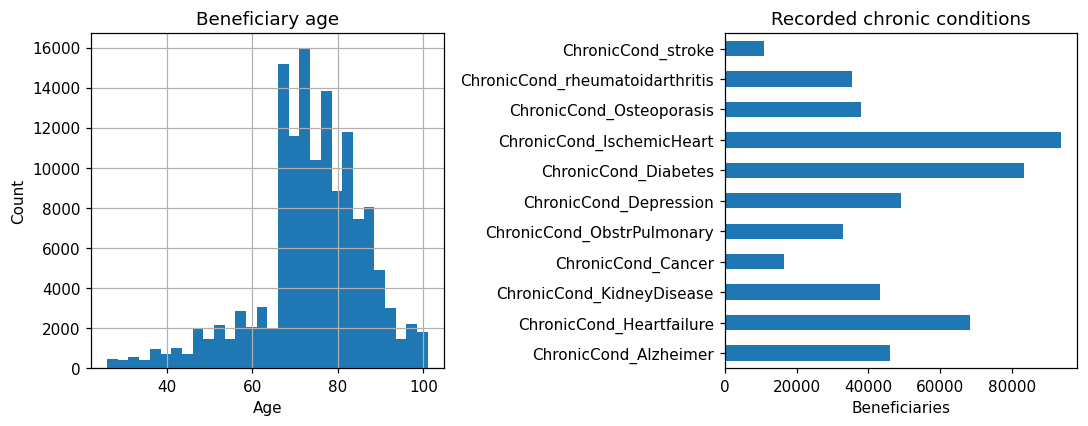

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_beneficiaries["Age"].hist(bins=30, ax=axes[0])
axes[0].set(title="Beneficiary age", xlabel="Age", ylabel="Count")
train_beneficiaries[chronic_columns].sum().plot.barh(ax=axes[1])
axes[1].set(title="Recorded chronic conditions", xlabel="Beneficiaries")
plt.tight_layout()
plt.show()

## 5. Combine claims and beneficiary details
Stack inpatient and outpatient rows, then join beneficiary details. The checked many-to-one join prevents duplicate beneficiary rows from multiplying claims.

In [6]:
for df in [train_inpatient, test_inpatient]:
    df["AdmissionDt"] = pd.to_datetime(df["AdmissionDt"], errors="coerce")
    df["DischargeDt"] = pd.to_datetime(df["DischargeDt"], errors="coerce")
    df["InHospitalDays"] = (df["DischargeDt"] - df["AdmissionDt"]).dt.days + 1

train_claims = pd.concat([train_outpatient, train_inpatient], ignore_index=True)
test_claims = pd.concat([test_outpatient, test_inpatient], ignore_index=True)
assert train_claims["ClaimID"].is_unique
assert test_claims["ClaimID"].is_unique
assert train_claims["BeneID"].isin(train_beneficiaries["BeneID"]).all()
assert test_claims["BeneID"].isin(test_beneficiaries["BeneID"]).all()

train_claims = train_claims.merge(train_beneficiaries, on="BeneID", validate="many_to_one")
test_claims = test_claims.merge(test_beneficiaries, on="BeneID", validate="many_to_one")
print("Train claims:", train_claims.shape)
print("Test claims:", test_claims.shape)

Train claims: (558211, 57)
Test claims: (135392, 57)


## 6. Prepare claim features
The following calculations and zero-fill conventions retain the original feature definitions. Train and test provider IDs are disjoint; aggregation is local to each provider, with no learned scaling or imputation here.

In [7]:
claims = pd.concat([train_claims, test_claims], ignore_index=True)

numeric_columns = [
    "InscClaimAmtReimbursed", "DeductibleAmtPaid", "InHospitalDays", "Age",
    "IPAnnualReimbursementAmt", "IPAnnualDeductibleAmt",
    "OPAnnualReimbursementAmt", "OPAnnualDeductibleAmt",
]
for column in numeric_columns:
    claims[column] = pd.to_numeric(claims[column], errors="coerce").fillna(0)

for column in ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt"]:
    claims[column] = pd.to_datetime(claims[column], errors="coerce")

In [8]:
claims["ClaimDurationDays"] = (
    claims["ClaimEndDt"] - claims["ClaimStartDt"]
).dt.days.add(1).clip(lower=1).fillna(1)

claims["IsInpatient"] = claims["AdmissionDt"].notna().astype(int)

diagnosis_columns = [
    column for column in claims.columns
    if column.startswith("ClmDiagnosisCode_")
]

procedure_columns = [
    column for column in claims.columns
    if column.startswith("ClmProcedureCode_")
]

physician_columns = [
    column for column in [
        "AttendingPhysician",
        "OperatingPhysician",
        "OtherPhysician",
    ]
    if column in claims.columns
]

claims["DiagnosisCount"] = claims[diagnosis_columns].notna().sum(axis=1)
claims["ProcedureCount"] = claims[procedure_columns].notna().sum(axis=1)
claims["PhysicianCount"] = claims[physician_columns].notna().sum(axis=1)

chronic_columns = [
    column for column in claims.columns
    if column.startswith("ChronicCond_")
]

claims["ChronicConditionCount"] = claims[chronic_columns].sum(axis=1)

claims["AnnualReimbursementTotal"] = (
    claims["IPAnnualReimbursementAmt"]
    + claims["OPAnnualReimbursementAmt"]
)

claims["AnnualDeductibleTotal"] = (
    claims["IPAnnualDeductibleAmt"]
    + claims["OPAnnualDeductibleAmt"]
)

claims[
    [
        "ClaimDurationDays",
        "IsInpatient",
        "DiagnosisCount",
        "ProcedureCount",
        "PhysicianCount",
        "ChronicConditionCount",
    ]
].describe().T

Out[0]: 
                          count      mean       std  min  25%  50%  75%   max
ClaimDurationDays      693603.0  2.726439  4.905386  1.0  1.0  1.0  1.0  37.0
IsInpatient            693603.0  0.072123  0.258692  0.0  0.0  0.0  0.0   1.0
DiagnosisCount         693603.0  3.007330  2.445533  0.0  1.0  2.0  4.0  10.0
ProcedureCount         693603.0  0.053175  0.279470  0.0  0.0  0.0  0.0   5.0
PhysicianCount         693603.0  1.559618  0.639362  0.0  1.0  1.0  2.0   3.0
ChronicConditionCount  693603.0  4.501150  2.333040  0.0  3.0  5.0  6.0  11.0


## 7. Aggregate claims into provider features
Retain the original `build_provider_features` function and all 33 features.

In [9]:
def build_provider_features(data):
    provider = data.groupby("Provider").agg(
        ClaimCount=("ClaimID", "count"),
        UniqueBeneficiaries=("BeneID", "nunique"),

        ReimbursementTotal=("InscClaimAmtReimbursed", "sum"),
        ReimbursementMean=("InscClaimAmtReimbursed", "mean"),
        ReimbursementMedian=("InscClaimAmtReimbursed", "median"),
        ReimbursementStd=("InscClaimAmtReimbursed", "std"),
        ReimbursementMax=("InscClaimAmtReimbursed", "max"),

        DeductibleTotal=("DeductibleAmtPaid", "sum"),
        DeductibleMean=("DeductibleAmtPaid", "mean"),
        DeductibleMax=("DeductibleAmtPaid", "max"),

        InpatientClaimCount=("IsInpatient", "sum"),
        InpatientClaimRatio=("IsInpatient", "mean"),

        ClaimDurationMean=("ClaimDurationDays", "mean"),
        HospitalStayMean=("InHospitalDays", "mean"),
        HospitalStayMax=("InHospitalDays", "max"),

        DiagnosisCountMean=("DiagnosisCount", "mean"),
        ProcedureCountMean=("ProcedureCount", "mean"),
        PhysicianCountMean=("PhysicianCount", "mean"),

        BeneficiaryAgeMean=("Age", "mean"),
        BeneficiaryAgeStd=("Age", "std"),
        ChronicConditionMean=("ChronicConditionCount", "mean"),

        AnnualReimbursementMean=("AnnualReimbursementTotal", "mean"),
        AnnualDeductibleMean=("AnnualDeductibleTotal", "mean"),

        UniqueAttendingPhysicians=("AttendingPhysician", "nunique"),
        UniquePrimaryDiagnoses=("ClmDiagnosisCode_1", "nunique"),
        UniquePrimaryProcedures=("ClmProcedureCode_1", "nunique"),
    ).reset_index()

    provider["ClaimsPerBeneficiary"] = (
        provider["ClaimCount"]
        / provider["UniqueBeneficiaries"].replace(0, np.nan)
    )

    provider["ReimbursementPerBeneficiary"] = (
        provider["ReimbursementTotal"]
        / provider["UniqueBeneficiaries"].replace(0, np.nan)
    )

    provider["ReimbursementPerClaim"] = (
        provider["ReimbursementTotal"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    provider["DeductibleToReimbursementRatio"] = (
        provider["DeductibleTotal"]
        / provider["ReimbursementTotal"].replace(0, np.nan)
    )

    provider["PhysicianDiversityRatio"] = (
        provider["UniqueAttendingPhysicians"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    provider["DiagnosisDiversityRatio"] = (
        provider["UniquePrimaryDiagnoses"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    provider["ProcedureDiversityRatio"] = (
        provider["UniquePrimaryProcedures"]
        / provider["ClaimCount"].replace(0, np.nan)
    )

    return (
        provider
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )


provider_features = build_provider_features(claims)

print("Provider-level shape:", provider_features.shape)
provider_features.head()

Provider-level shape: (6763, 34)
Out[0]: 
   Provider  ClaimCount  ...  DiagnosisDiversityRatio  ProcedureDiversityRatio
0  PRV51001          25  ...                 0.920000                 0.080000
1  PRV51002         205  ...                 0.848780                 0.000000
2  PRV51003         132  ...                 0.871212                 0.242424
3  PRV51004         149  ...                 0.859060                 0.000000
4  PRV51005        1165  ...                 0.694421                 0.000000

[5 rows x 34 columns]


## 8. Build train_df and test_df
These names, labels and feature columns match the modeling notebook.

In [10]:
train_df = (
    train_providers[["Provider", "PotentialFraud"]]
    .merge(provider_features, on="Provider", how="left", validate="one_to_one")
)

test_df = (
    test_providers[["Provider"]]
    .merge(provider_features, on="Provider", how="left", validate="one_to_one")
)

feature_columns = [
    column for column in train_df.columns
    if column not in ["Provider", "PotentialFraud"]
]

train_df[feature_columns] = (
    train_df[feature_columns].fillna(0)
)

test_df[feature_columns] = (
    test_df[feature_columns].fillna(0)
)

train_df["FraudLabel"] = (
    train_df["PotentialFraud"]
    .map({"No": 0, "Yes": 1})
)

print("train_providers provider data:", train_df.shape)
print("test_providers provider data:", test_df.shape)
print()
print(train_df["PotentialFraud"].value_counts())

train_providers provider data: (5410, 36)
test_providers provider data: (1353, 34)

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


## 9. Explore the training partition
Use the same 75% training split and seed 42 as modeling for label-based feature comparisons. The reserved validation rows are not used in the following plots or correlations.

EDA training providers: 4057
Reserved validation providers: 1353


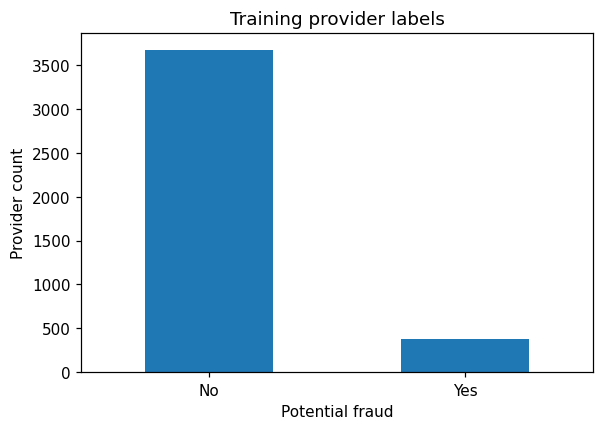

In [11]:
eda_train, eda_valid = train_test_split(
    train_df, test_size=0.25, random_state=RANDOM_STATE,
    stratify=train_df["FraudLabel"],
)
print("EDA training providers:", len(eda_train))
print("Reserved validation providers:", len(eda_valid))

label_counts = eda_train["PotentialFraud"].value_counts().reindex(["No", "Yes"])
label_counts.plot.bar(rot=0, figsize=(6, 4))
plt.title("Training provider labels")
plt.xlabel("Potential fraud")
plt.ylabel("Provider count")
plt.show()

In [12]:
comparison_features = [
    "ClaimCount",
    "UniqueBeneficiaries",
    "ReimbursementTotal",
    "ReimbursementPerClaim",
    "ClaimsPerBeneficiary",
    "InpatientClaimRatio",
    "DiagnosisCountMean",
    "ProcedureCountMean",
    "ChronicConditionMean",
]

fraud_comparison = (
    eda_train
    .groupby("PotentialFraud")[comparison_features]
    .median()
    .T
    .rename(
        columns={
            "No": "NonFraud_Median",
            "Yes": "Fraud_Median",
        }
    )
)

fraud_comparison["Fraud_to_NonFraud_Ratio"] = (
    fraud_comparison["Fraud_Median"]
    / fraud_comparison["NonFraud_Median"].replace(0, np.nan)
)

fraud_comparison.sort_values(
    "Fraud_to_NonFraud_Ratio",
    ascending=False,
)

Out[0]: 
PotentialFraud         NonFraud_Median   Fraud_Median  Fraud_to_NonFraud_Ratio
ReimbursementTotal        15315.000000  346360.000000                22.615736
ReimbursementPerClaim       333.381543    2730.000000                 8.188816
ClaimCount                   27.000000     145.000000                 5.370370
UniqueBeneficiaries          22.000000     109.000000                 4.954545
DiagnosisCountMean            2.762989       3.886667                 1.406689
ClaimsPerBeneficiary          1.083333       1.176471                 1.085973
ChronicConditionMean          4.500000       4.724638                 1.049919
InpatientClaimRatio           0.000000       0.238095                      NaN
ProcedureCountMean            0.000000       0.177570                      NaN


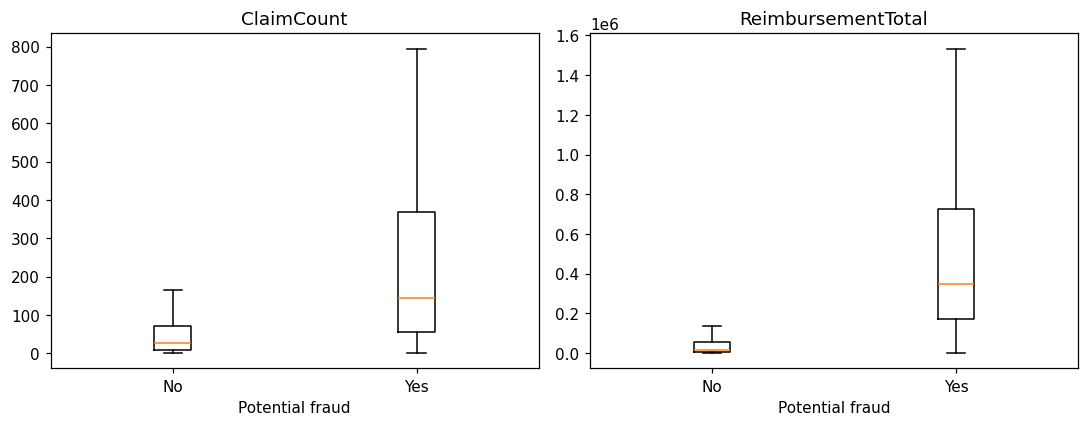

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for feature, ax in zip(["ClaimCount", "ReimbursementTotal"], axes):
    groups = [eda_train.loc[eda_train["PotentialFraud"] == label, feature] for label in ["No", "Yes"]]
    ax.boxplot(groups, tick_labels=["No", "Yes"], showfliers=False)
    ax.set(title=feature, xlabel="Potential fraud")
plt.tight_layout()
plt.show()

## 10. Inspect feature correlations
Correlations are exploratory associations, not causal explanations. All predefined features remain in modeling.

In [14]:
numeric_features = eda_train.select_dtypes(include=np.number)

fraud_correlations = (
    numeric_features
    .corr()["FraudLabel"]
    .drop("FraudLabel")
    .sort_values(key=abs, ascending=False)
)

fraud_correlations.head(15).to_frame(
    "CorrelationWithFraud"
)

Out[0]: 
                             CorrelationWithFraud
ReimbursementTotal                       0.561599
UniquePrimaryProcedures                  0.556449
HospitalStayMax                          0.543948
ReimbursementMax                         0.527631
DeductibleTotal                          0.519305
InpatientClaimCount                      0.513634
UniqueBeneficiaries                      0.379401
UniquePrimaryDiagnoses                   0.375578
ClaimCount                               0.364995
ReimbursementStd                         0.362993
DiagnosisDiversityRatio                 -0.350812
DeductibleMax                            0.331327
UniqueAttendingPhysicians                0.271230
ReimbursementPerBeneficiary              0.240295
ReimbursementMean                        0.213792


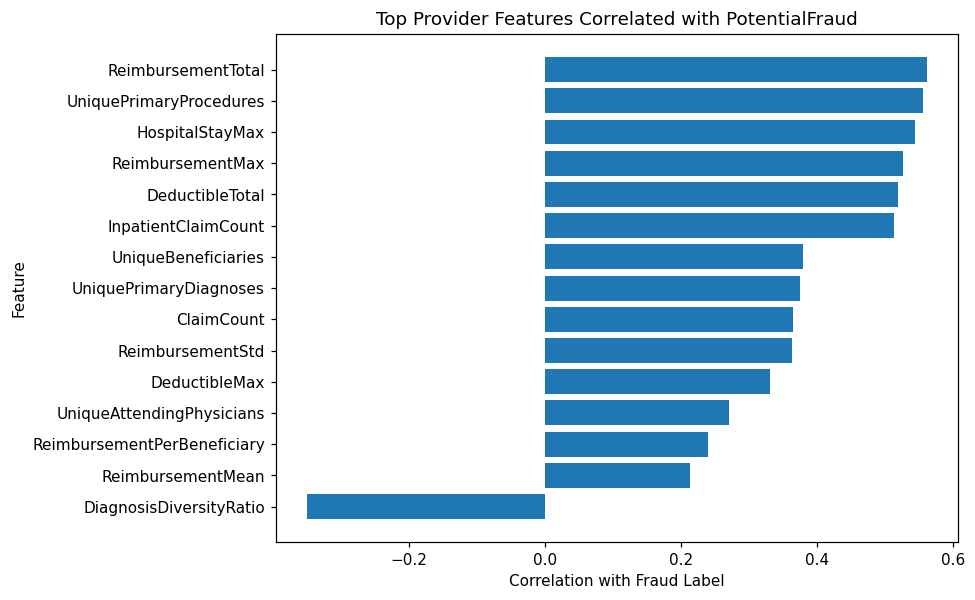

In [15]:
top_correlations = (
    fraud_correlations
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_correlations.index,
    top_correlations.values,
)
plt.title("Top Provider Features Correlated with PotentialFraud")
plt.xlabel("Correlation with Fraud Label")
plt.ylabel("Feature")
plt.show()

## 11. Check and save the modeling inputs

In [16]:
X = train_df.drop(
    columns=[
        "Provider",
        "PotentialFraud",
        "FraudLabel",
    ]
)

y = train_df["FraudLabel"]

X_test = test_df.drop(
    columns=["Provider"]
)

X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("Aligned columns:", X.columns.equals(X_test.columns))

assert train_df["Provider"].is_unique
assert test_df["Provider"].is_unique
assert y.isin([0, 1]).all()
assert X.shape[1] == 33
assert np.isfinite(X.to_numpy()).all()
assert np.isfinite(X_test.to_numpy()).all()


X shape: (5410, 33)
y shape: (5410,)
X_test shape: (1353, 33)
Aligned columns: True


In [17]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

train_output = PROCESSED_DATA_DIR / "train_provider_features.csv"
test_output = PROCESSED_DATA_DIR / "test_provider_features.csv"
comparison_output = PROCESSED_DATA_DIR / "fraud_feature_comparison.csv"
correlation_output = PROCESSED_DATA_DIR / "fraud_feature_correlations.csv"

train_df.to_csv(train_output, index=False)
test_df.to_csv(test_output, index=False)
fraud_comparison.to_csv(comparison_output)
fraud_correlations.to_csv(
    correlation_output,
    header=["CorrelationWithFraud"],
)

print("Saved processed files:")
print("-", train_output.resolve())
print("-", test_output.resolve())
print("-", comparison_output.resolve())
print("-", correlation_output.resolve())

Saved processed files:
- /workspace/scratch/7d20b19070a5/minimal_smote/CMS_Fraud_Project_Portable_Final/data/processed/train_provider_features.csv
- /workspace/scratch/7d20b19070a5/minimal_smote/CMS_Fraud_Project_Portable_Final/data/processed/test_provider_features.csv
- /workspace/scratch/7d20b19070a5/minimal_smote/CMS_Fraud_Project_Portable_Final/data/processed/fraud_feature_comparison.csv
- /workspace/scratch/7d20b19070a5/minimal_smote/CMS_Fraud_Project_Portable_Final/data/processed/fraud_feature_correlations.csv


## Next step

Open **02_Modeling.ipynb**. It reads these same CSV files, splits the labeled providers, fits scaling and SMOTE on training rows only, then compares Logistic Regression, Random Forest, XGBoost, KNN and SVM.

